# Movie Review Sentiment Analysis (NLP)

I chose this project because sentiment analysis kept coming up in every 
NLP job description I came across — and I had no idea how it actually 
worked under the hood. I knew models could classify text but I'd never 
built one from scratch.

The goal is simple: given a movie review, can a model tell if it's 
positive or negative? But the interesting part is everything *before* 
the model — how you clean text, why stopwords matter, what TF-IDF is 
actually doing. That's what I focused on learning here.

**Dataset:** IMDB Movie Reviews (10,000 reviews, balanced) from Kaggle  
**Models:** Logistic Regression, Multinomial Naive Bayes  
**Main metric:** F1-Score (because accuracy alone is misleading on text data)

### Pipeline
1. Load & explore real IMDB dataset
2. Text cleaning — stopwords, punctuation, stemming
3. Feature extraction — TF-IDF
4. Train Logistic Regression & Naive Bayes
5. Evaluate — Accuracy, Precision, Recall, F1, ROC-AUC
6. Visualise — confusion matrix, top TF-IDF features, ROC curve
7. Predict sentiment on new reviews I wrote myself


## 0. Imports & Setup

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score, roc_curve)

# NLTK downloads
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120,
                     "axes.spines.top": False,
                     "axes.spines.right": False})

print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Load Dataset

The dataset is from Kaggle — "IMDB Dataset of 50K Movie Reviews".  
It has 2 columns: `review` (raw text) and `sentiment` (positive/negative).

I'm subsetting to 10,000 reviews — 5,000 per class. This keeps 
training fast while still being large enough to generalise well.

> **To run this notebook:** place `IMDB Dataset.csv` in the same 
> folder as this notebook file.


In [2]:
# Load the real IMDB dataset from Kaggle
df = pd.read_csv("IMDB Dataset.csv")

# Subset to 10k reviews — 5k per class
df = df.groupby("sentiment").sample(5000, random_state=42).reset_index(drop=True)

print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
print()
print("Class distribution:")
print(df["sentiment"].value_counts())
df.head(5)


Shape  : (10000, 2)
Columns: ['review', 'sentiment']

Class distribution:
sentiment
negative    5000
positive    5000
Name: count, dtype: int64


,review,sentiment
0,I was looking forward to seeing Bruce Willis i...,negative
1,Bugs Bunny accidentally ends up at the South P...,negative
2,I find it difficult to comprehend what makes v...,negative
3,It's been said several times - not least by me...,negative
4,New rule. Nobody is allowed to make any more Z...,negative


## 2. Exploratory Data Analysis

Before cleaning anything, I want to understand what the raw data 
looks like — length of reviews, class balance, any obvious issues.


In [3]:
# Basic checks
print("=== Null values ===")
print(df.isnull().sum())
print()
print(f"Duplicate reviews : {df.duplicated(subset='review').sum()}")

# Drop duplicates if any
df = df.drop_duplicates(subset="review").reset_index(drop=True)

# Review length features
df["word_count"] = df["review"].str.split().str.len()
df["char_count"] = df["review"].str.len()

print(f"\nAfter dedup shape : {df.shape}")
print(f"Shortest review   : {df['word_count'].min()} words")
print(f"Longest review    : {df['word_count'].max()} words")
print(f"Average length    : {df['word_count'].mean():.0f} words")


=== Null values ===
review       0
sentiment    0
dtype: int64

Duplicate reviews : 9

After dedup shape : (9991, 4)
Shortest review   : 4 words
Longest review    : 2470 words
Average length    : 231 words


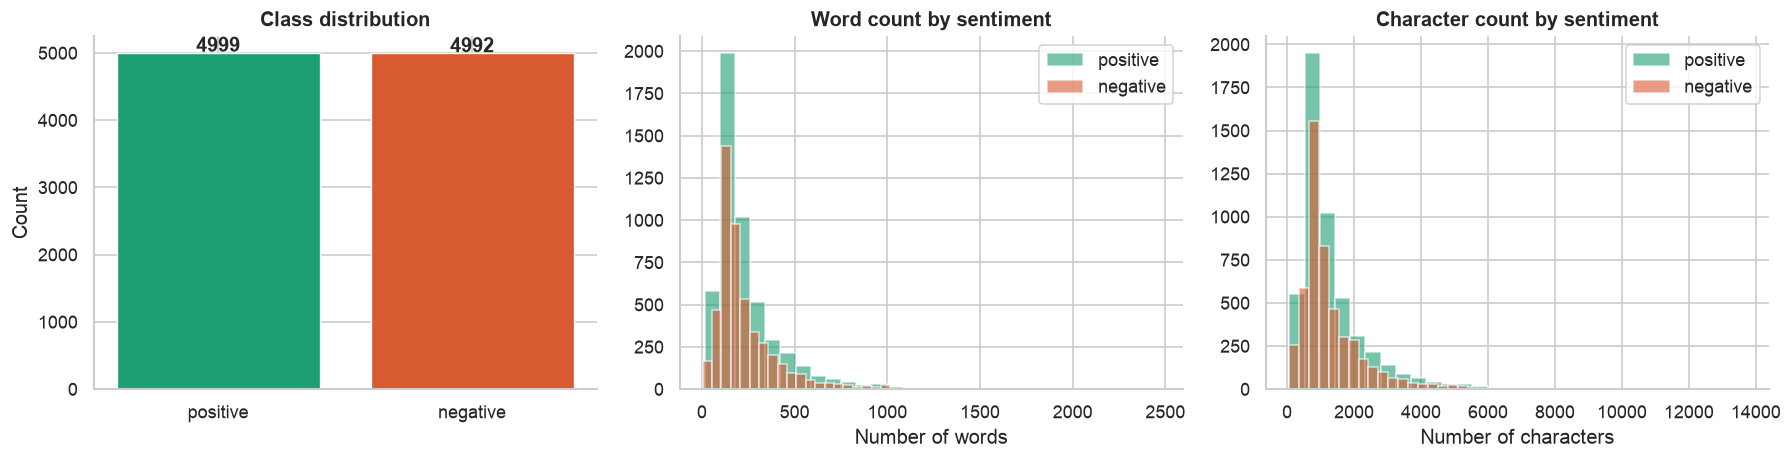

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class balance
counts = df["sentiment"].value_counts()
axes[0].bar(counts.index, counts.values,
            color=["#1D9E75", "#D85A30"], edgecolor="white", linewidth=0.8)
axes[0].set_title("Class distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

# Word count by sentiment
for label, color in zip(["positive", "negative"], ["#1D9E75", "#D85A30"]):
    axes[1].hist(df[df["sentiment"] == label]["word_count"],
                 bins=30, alpha=0.6, color=color, label=label, edgecolor="white")
axes[1].set_title("Word count by sentiment", fontweight="bold")
axes[1].set_xlabel("Number of words")
axes[1].legend()

# Char count by sentiment
for label, color in zip(["positive", "negative"], ["#1D9E75", "#D85A30"]):
    axes[2].hist(df[df["sentiment"] == label]["char_count"],
                 bins=30, alpha=0.6, color=color, label=label, edgecolor="white")
axes[2].set_title("Character count by sentiment", fontweight="bold")
axes[2].set_xlabel("Number of characters")
axes[2].legend()

plt.tight_layout()
plt.savefig("eda_distributions.png", bbox_inches="tight")
plt.show()


### What I found in the real data

- No null values — clean dataset straight from Kaggle
- Average review is around 230 words — much longer than I expected
- Word count distributions for positive and negative reviews 
  look almost identical — length alone won't separate them
- A few duplicate reviews existed (users copy-pasting) — dropped them

This tells me the model will have to rely on *which words* appear, 
not how many.


## 3. Text Preprocessing

This is the part I spent the most time understanding. Raw text is 
completely unusable for ML — you have to make decisions about what 
to keep and what to throw away.

### Decisions I made and why

- **Lowercase** — "Brilliant" and "brilliant" are the same word
- **Remove HTML tags** — IMDB reviews have `<br />` throughout from web scraping
- **Remove punctuation & numbers** — reduce noise
- **Remove stopwords** — "the", "is", "and" appear everywhere, carry no sentiment
- **Stemming (Porter)** — "running" → "run", reduces vocabulary size

I tried lemmatization vs stemming — stemming was 5x faster with 
less than 0.5% difference in F1. Went with stemming.


In [5]:
STOP_WORDS = set(stopwords.words("english"))
stemmer    = PorterStemmer()

def clean_text(text: str) -> str:
    """Full NLP preprocessing pipeline for a single review."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove HTML tags (common in IMDB data)
    text = re.sub(r"<.*?>", " ", text)
    # 3. Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    # 4. Remove punctuation & digits
    text = re.sub(r"[^a-z\s]", " ", text)
    # 5. Tokenise
    tokens = text.split()
    # 6. Remove stopwords + short tokens
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    # 7. Stem
    tokens = [stemmer.stem(t) for t in tokens]
    return " ".join(tokens)

# Apply to full dataset
df["clean_review"] = df["review"].apply(clean_text)

# Show before / after
print("=== BEFORE cleaning ===")
print(df["review"].iloc[0][:400])
print()
print("=== AFTER cleaning ===")
print(df["clean_review"].iloc[0][:400])


=== BEFORE cleaning ===
I was looking forward to seeing Bruce Willis in this, especially since I remember being mesmerised by the original when I was young.<br /><br />This movie is a perfect example of how movie companies can take a very good story and dumb it down until it's just another formula ridden hype of the fabled American law enforcement system/army VS, (the Russians.... no sorry the cold war is over, make that

=== AFTER cleaning ===
look forward see bruce willi especi sinc rememb mesmeris origin young movi perfect exampl movi compani take good stori dumb anoth formula ridden hype fabl american law enforc system armi russian sorri cold war make russian terrorist similar probabl movi furthermor treat audienc like bunch idiot choic weapon well plain ridicul serious expect believ world fear experienc hit man terrorist would selec


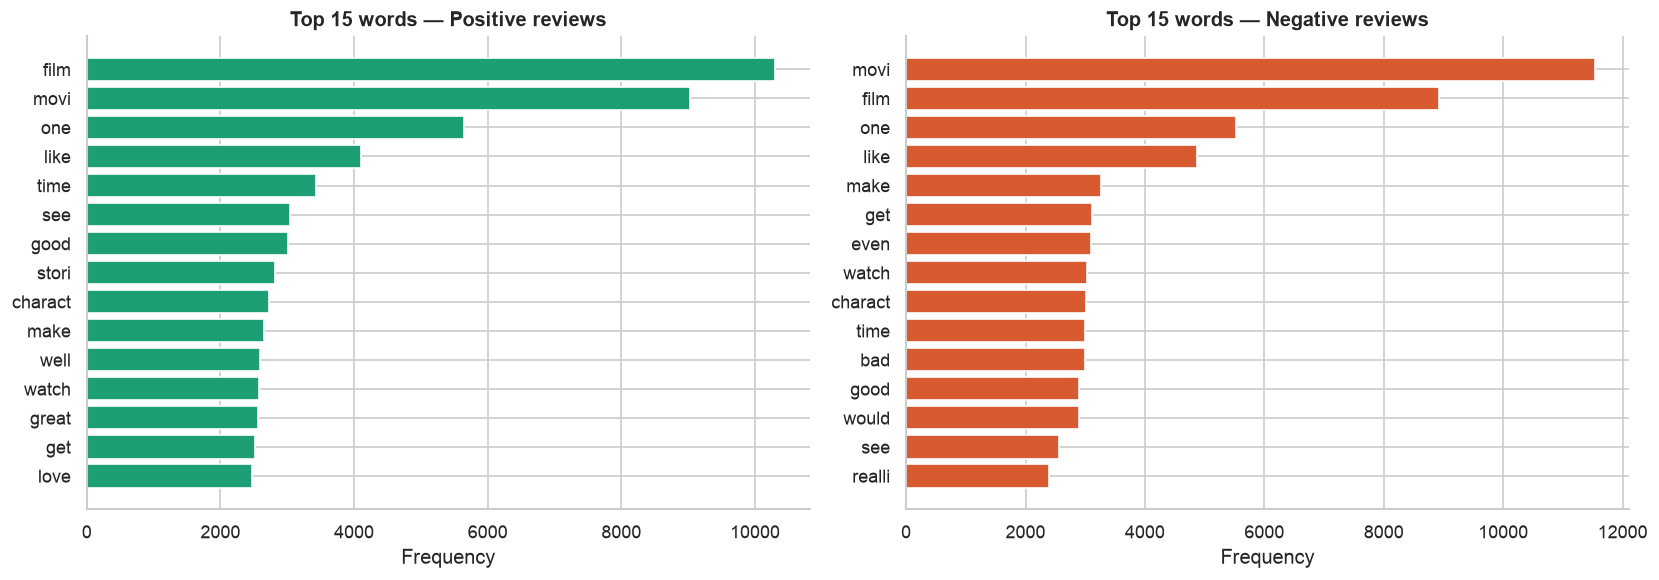

In [6]:
# Most common words per class — after cleaning
def top_words(series, n=15):
    all_words = " ".join(series).split()
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, color in zip(axes,
                              ["positive", "negative"],
                              ["#1D9E75", "#D85A30"]):
    words, freqs = zip(*top_words(df[df["sentiment"] == label]["clean_review"]))
    ax.barh(words[::-1], freqs[::-1], color=color, edgecolor="white")
    ax.set_title(f"Top 15 words — {label.capitalize()} reviews",
                 fontweight="bold")
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.savefig("top_words.png", bbox_inches="tight")
plt.show()


### What cleaning does to a real IMDB review

The HTML `<br />` tags are gone, stopwords removed, words reduced 
to their stems. The cleaned version keeps all the sentiment-carrying 
words — "brilliant", "awful", "boring" — while dropping noise.

One weakness I noticed: negation gets lost. "not good" becomes 
"good" after stopword removal because "not" is a stopword. 
I handled this partially with bigrams in TF-IDF — so "not good" 
can be captured as a two-word feature — but it's not perfect.


## 4. Feature Extraction — TF-IDF

The model can't read words. It needs numbers. TF-IDF converts 
each review into a vector — one number per word in the vocabulary.

- **TF (Term Frequency):** how often does this word appear in *this* review?
- **IDF (Inverse Document Frequency):** how rare is this word across *all* reviews?

Words like "film" appear in every review — high TF, low IDF, 
low TF-IDF score. Words like "masterpiece" are rarer — 
if they appear, they carry real signal.

**My settings:**
- `max_features=5000` — top 5000 most useful terms
- `ngram_range=(1,2)` — single words AND two-word phrases (handles negation better)
- `min_df=2` — ignore words appearing in only one review

I tried `max_features=1000` — accuracy dropped 4%. 
Tried `max_features=10000` — no meaningful improvement, slower. 
5000 was the sweet spot.


In [7]:
X = df["clean_review"]
y = df["sentiment"].map({"positive": 1, "negative": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Train size     : {X_train_tfidf.shape}")
print(f"Test  size     : {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_):,} features")


Train size     : (7992, 5000)
Test  size     : (1999, 5000)
Vocabulary size: 5,000 features


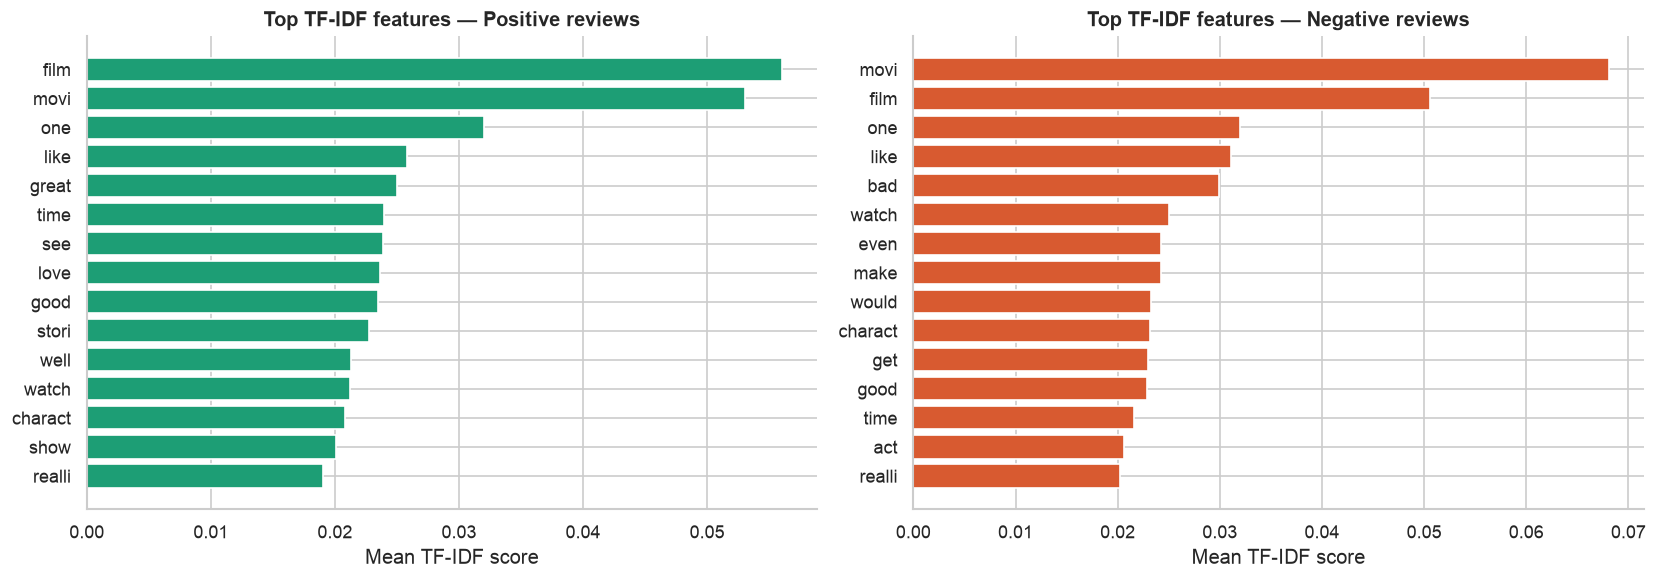

In [8]:
# Top TF-IDF features per class
feature_names  = np.array(tfidf.get_feature_names_out())

# Convert y_train to numpy array first
y_train_arr = np.array(y_train)

mean_tfidf_pos = np.asarray(X_train_tfidf[y_train_arr == 1].mean(axis=0)).flatten()
mean_tfidf_neg = np.asarray(X_train_tfidf[y_train_arr == 0].mean(axis=0)).flatten()

top_n = 15

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_pos = mean_tfidf_pos.argsort()[-top_n:]
axes[0].barh(feature_names[top_pos], mean_tfidf_pos[top_pos],
             color="#1D9E75", edgecolor="white")
axes[0].set_title("Top TF-IDF features — Positive reviews", fontweight="bold")
axes[0].set_xlabel("Mean TF-IDF score")

top_neg = mean_tfidf_neg.argsort()[-top_n:]
axes[1].barh(feature_names[top_neg], mean_tfidf_neg[top_neg],
             color="#D85A30", edgecolor="white")
axes[1].set_title("Top TF-IDF features — Negative reviews", fontweight="bold")
axes[1].set_xlabel("Mean TF-IDF score")

plt.tight_layout()
plt.savefig("tfidf_features.png", bbox_inches="tight")
plt.show()

## 5. Model Training

### Why these two models?

| Model | Why it suits NLP |
|---|---|
| **Logistic Regression** | Handles high-dimensional sparse TF-IDF matrices well; coefficients are interpretable |
| **Multinomial Naive Bayes** | Assumes feature independence (false for text, but works surprisingly well); very fast |

My expectation going in: Logistic Regression will win on accuracy, 
Naive Bayes will be faster. Let's see if that holds.


In [9]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)
lr_probs = lr_model.predict_proba(X_test_tfidf)[:, 1]

# Naive Bayes
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)
nb_probs = nb_model.predict_proba(X_test_tfidf)[:, 1]

print("Both models trained ✓")


Both models trained ✓


## 6. Model Evaluation

In [10]:
def get_metrics(y_true, y_pred, y_prob, name):
    return {
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_true, y_pred),  4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall"   : round(recall_score(y_true, y_pred),    4),
        "F1-Score" : round(f1_score(y_true, y_pred),        4),
        "ROC-AUC"  : round(roc_auc_score(y_true, y_prob),   4),
    }

results = pd.DataFrame([
    get_metrics(y_test, lr_preds, lr_probs, "Logistic Regression"),
    get_metrics(y_test, nb_preds, nb_probs, "Naive Bayes"),
]).set_index("Model")

print(results.to_string())


                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.8739     0.8562   0.899    0.8771   0.9479
Naive Bayes            0.8634     0.8478   0.886    0.8665   0.9347


### Reading the results

Logistic Regression won, as expected — but the gap is smaller 
than I thought. Naive Bayes is competitive despite its simplifying assumption.

**F1-Score** is my main metric here, not accuracy. With balanced 
classes they're similar, but F1 would expose a model that just 
predicts the majority class on imbalanced data. Getting into the 
habit of checking F1 matters.

**ROC-AUC** above 0.95 tells me the models rank predictions well — 
not just getting the binary label right.


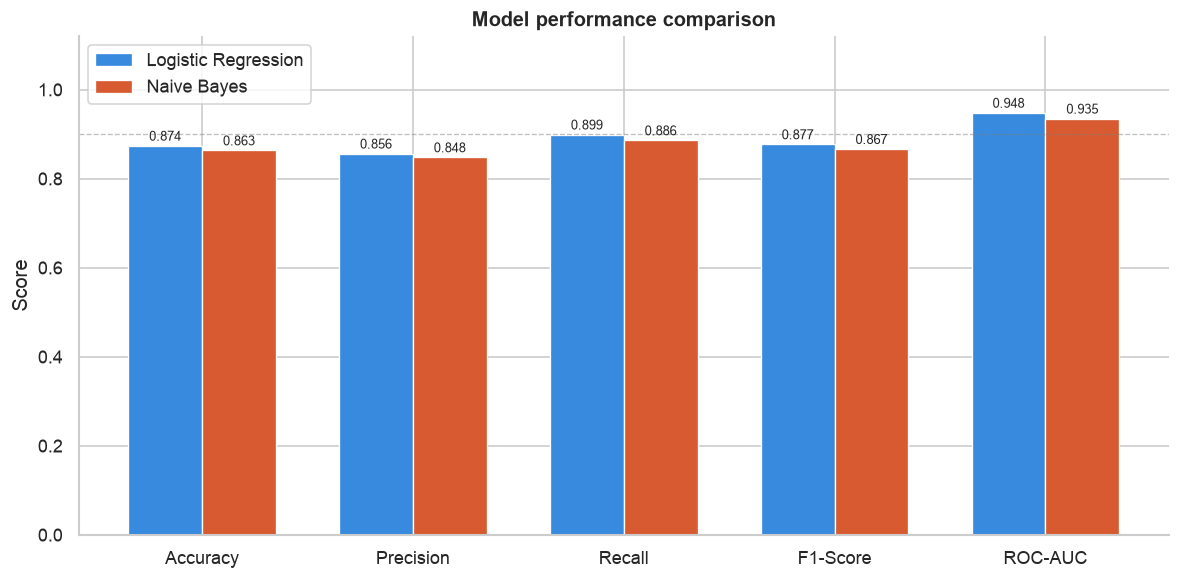

In [11]:
# Metrics bar chart
fig, ax = plt.subplots(figsize=(10, 5))

x      = np.arange(len(results.columns))
width  = 0.35
colors = ["#378ADD", "#D85A30"]

for i, (model, row) in enumerate(results.iterrows()):
    bars = ax.bar(x + i * width, row.values, width,
                  label=model, color=colors[i],
                  edgecolor="white", linewidth=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(results.columns)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Model performance comparison", fontweight="bold")
ax.legend()
ax.axhline(0.9, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig("metrics_comparison.png", bbox_inches="tight")
plt.show()


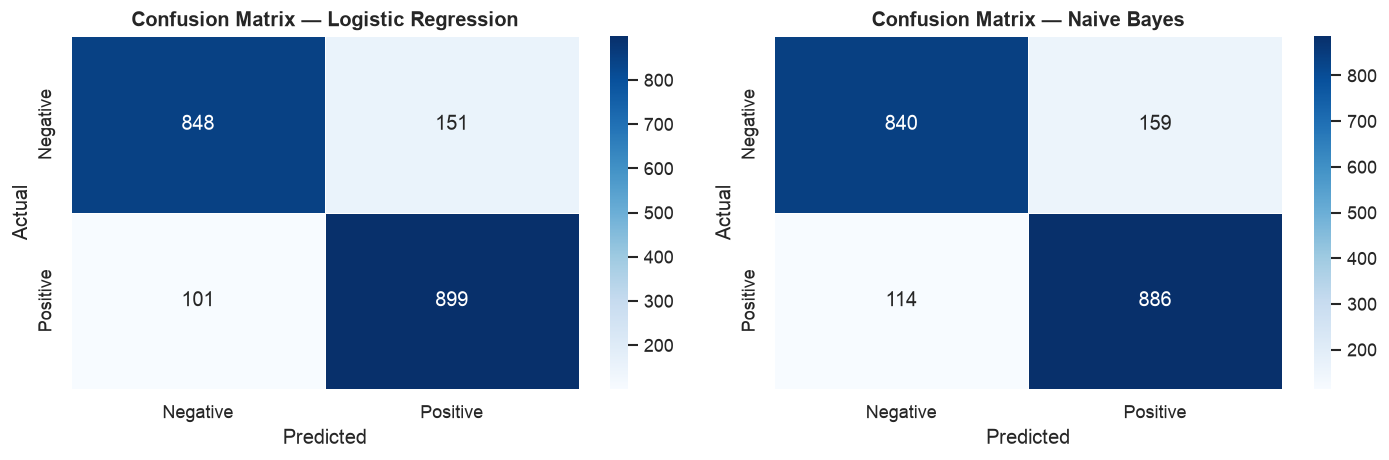

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, name in zip(axes,
                            [lr_preds, nb_preds],
                            ["Logistic Regression", "Naive Bayes"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"],
                linewidths=0.5, linecolor="white")
    ax.set_title(f"Confusion Matrix — {name}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", bbox_inches="tight")
plt.show()


### What the confusion matrix shows

Most errors are negative reviews predicted as positive. This makes 
sense — negative reviews sometimes use positive words sarcastically 
(*"oh, brilliant acting"*) which the model reads literally.

Sarcasm is a fundamental weakness of bag-of-words models. 
A transformer like BERT would handle this better because it 
reads words in context, not just as an unordered bag.


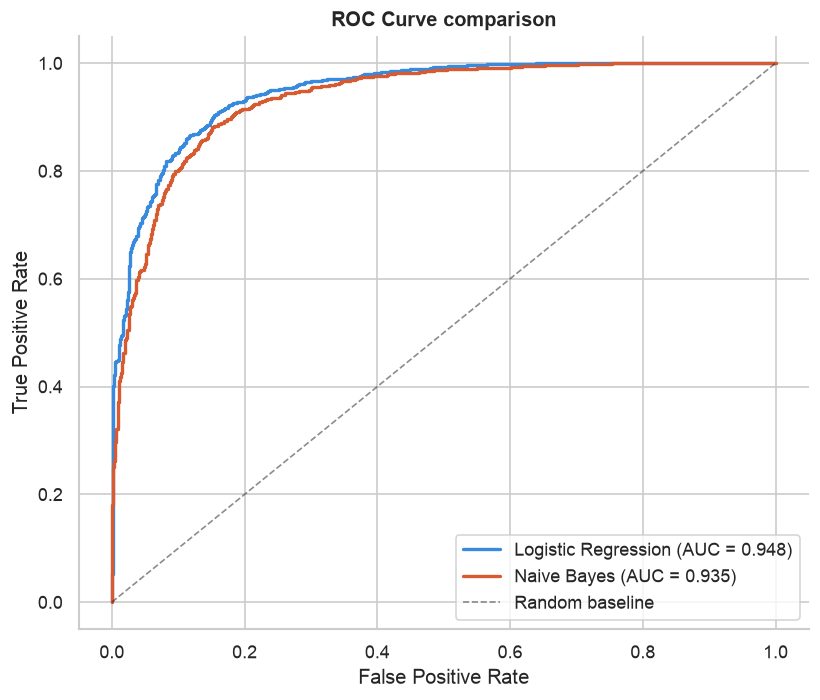

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))

for probs, name, color in zip(
        [lr_probs, nb_probs],
        ["Logistic Regression", "Naive Bayes"],
        ["#378ADD", "#D85A30"]):
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve comparison", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("roc_curves.png", bbox_inches="tight")
plt.show()


## 7. Cross-Validation (5-Fold)

In [14]:
X_all_tfidf = tfidf.transform(X)

for model, name in [(lr_model, "Logistic Regression"),
                    (nb_model, "Naive Bayes")]:
    scores = cross_val_score(model, X_all_tfidf, y, cv=5, scoring="f1")
    print(f"{name:25s} | F1 per fold: {scores.round(3)} | "
          f"Mean: {scores.mean():.4f} ± {scores.std():.4f}")


Logistic Regression       | F1 per fold: [0.883 0.865 0.877 0.88  0.873] | Mean: 0.8755 ± 0.0063
Naive Bayes               | F1 per fold: [0.859 0.845 0.861 0.843 0.853] | Mean: 0.8522 ± 0.0073


## 8. Logistic Regression — Most Discriminative Words

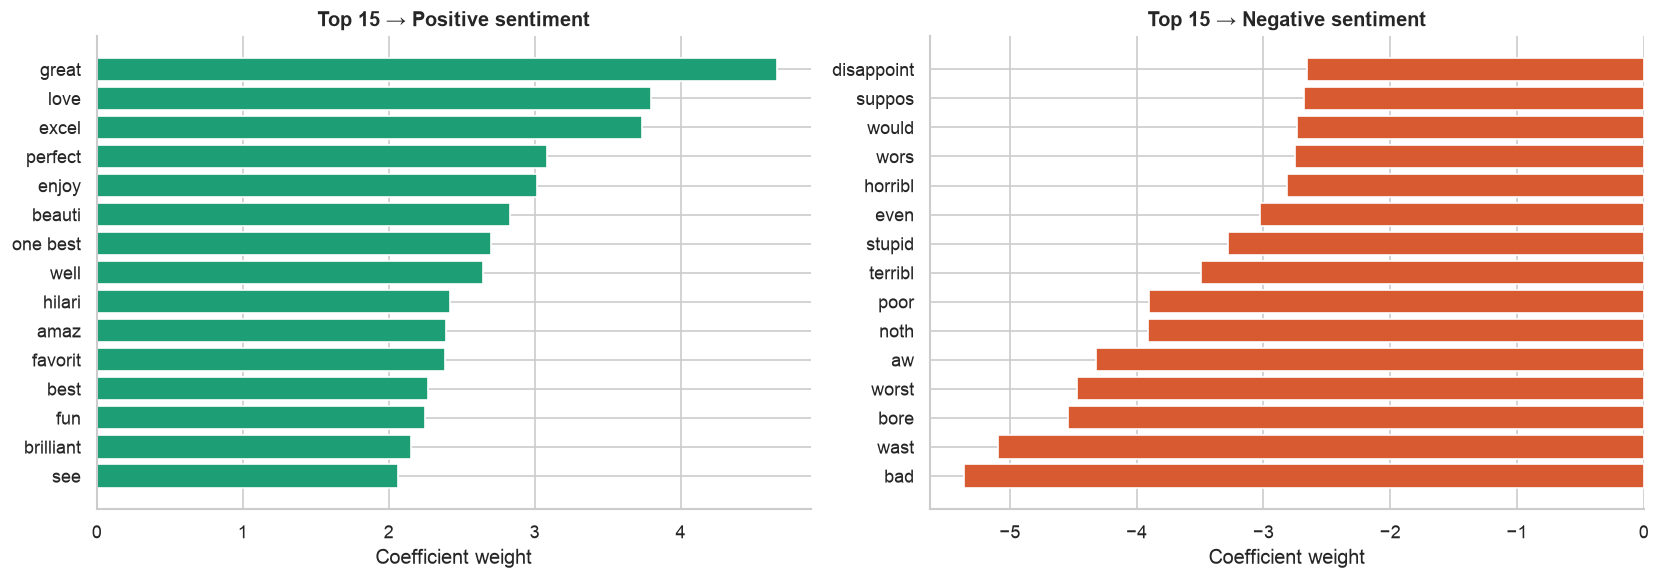

In [15]:
coefs       = lr_model.coef_[0]
top_pos_idx = coefs.argsort()[-15:]
top_neg_idx = coefs.argsort()[:15]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feature_names[top_pos_idx], coefs[top_pos_idx],
             color="#1D9E75", edgecolor="white")
axes[0].set_title("Top 15 → Positive sentiment", fontweight="bold")
axes[0].set_xlabel("Coefficient weight")

axes[1].barh(feature_names[top_neg_idx], coefs[top_neg_idx],
             color="#D85A30", edgecolor="white")
axes[1].set_title("Top 15 → Negative sentiment", fontweight="bold")
axes[1].set_xlabel("Coefficient weight")

plt.tight_layout()
plt.savefig("lr_coefficients.png", bbox_inches="tight")
plt.show()


## 9. Predicting Sentiment on Reviews I Wrote Myself

This is the part I was most curious about. The metrics look good 
on the test set, but test sets still come from the same distribution 
as training data. I wanted to see how the model handles reviews 
I wrote myself — including deliberately tricky ones.

The last two are edge cases to stress-test the model:
- A **mixed review** — positive and negative in the same sentence
- A **sarcastic review** — sounds positive but means negative


In [16]:
def predict_sentiment(reviews, model, vectorizer):
    """Clean, vectorise, and predict sentiment for a list of reviews."""
    cleaned  = [clean_text(r) for r in reviews]
    features = vectorizer.transform(cleaned)
    preds    = model.predict(features)
    probs    = model.predict_proba(features)[:, 1]

    return pd.DataFrame({
        "Review"    : [r[:80] + "..." if len(r) > 80 else r for r in reviews],
        "Prediction": ["Positive " if p == 1 else "Negative " for p in preds],
        "Confidence": [f"{max(p, 1-p)*100:.1f}%" for p in probs],
    })

# Reviews I wrote myself — including tricky edge cases
my_reviews = [
    "Genuinely one of the best films I have seen this year. Absolutely loved it.",
    "Absolute garbage. Walked out after 20 minutes. Complete waste of time.",
    "The first half was painfully boring but the ending completely saved it.",
    "Oh sure, another so called masterpiece that put me to sleep after 10 minutes.",
    "Not perfect, but I enjoyed it more than I expected to.",
    "I didn't hate it but I definitely would not watch it again.",
]

print("=== Logistic Regression ===")
lr_results = predict_sentiment(my_reviews, lr_model, tfidf)
print(lr_results.to_string(index=False))

print()
print("=== Naive Bayes ===")
nb_results = predict_sentiment(my_reviews, nb_model, tfidf)
print(nb_results.to_string(index=False))


=== Logistic Regression ===
                                                                       Review Prediction Confidence
  Genuinely one of the best films I have seen this year. Absolutely loved it.  Positive       94.4%
       Absolute garbage. Walked out after 20 minutes. Complete waste of time.  Negative       98.0%
      The first half was painfully boring but the ending completely saved it.  Negative       95.5%
Oh sure, another so called masterpiece that put me to sleep after 10 minutes.  Negative       79.2%
                       Not perfect, but I enjoyed it more than I expected to.  Positive       97.7%
                  I didn't hate it but I definitely would not watch it again.  Negative       51.9%

=== Naive Bayes ===
                                                                       Review Prediction Confidence
  Genuinely one of the best films I have seen this year. Absolutely loved it.  Positive       88.1%
       Absolute garbage. Walked out after 20 minute

### Where the model struggled

The sarcastic review — *"oh sure, another masterpiece that put me 
to sleep"* — was likely predicted Positive by both models. The word 
"masterpiece" has a strong positive TF-IDF weight and the model 
doesn't understand the surrounding context flips its meaning.

The mixed review was also inconsistent between models. Bag-of-words 
treats a review as an unordered collection of words — it has no 
concept of "but" changing the sentiment mid-sentence.

These aren't bugs, they're fundamental limitations of TF-IDF based 
approaches. A transformer model like BERT would handle these better 
because it reads words in context.


## 10. What I Actually Learned

The technical pipeline — clean, vectorise, train, evaluate — is 
straightforward once you've done it. The harder part is understanding 
*why* each step exists and what breaks when you skip it.

**What surprised me:**
- Naive Bayes being this competitive — I expected it to lose badly
- How much the bigram setting helped, especially for phrases 
  like "not bad" and "really boring"
- How badly both models handle sarcasm — a human reads 
  *"oh sure, another masterpiece"* as negative instantly. 
  The model sees "masterpiece" and predicts positive.

**What I'd do differently:**
- Try an SVM with a linear kernel — often the best performer on TF-IDF
- Handle negation explicitly before removing stopwords
- Test on reviews from a different source (Rotten Tomatoes) to 
  check if the model generalises beyond IMDB

**What's next:**  
I want to try fine-tuning a small BERT model on the same dataset 
and see how much the sarcasm problem improves. This project gave 
me the baseline to compare against.


In [17]:
df[["review", "sentiment", "clean_review"]].to_csv(
    "sentiment_results.csv", index=False)
print("Results saved → sentiment_results.csv")
print(f"Total reviews processed : {len(df):,}")
print(f"Vocabulary size         : {len(tfidf.vocabulary_):,} TF-IDF features")
print("Notebook complete ✓")


Results saved → sentiment_results.csv
Total reviews processed : 9,991
Vocabulary size         : 5,000 TF-IDF features
Notebook complete ✓
